# Hair Product Recommendation Model

## Loading dataset and exploring the data

In [1]:
#!python3.10 -m pip install pandas numpy scikit-learn xgboost matplotlib tensorflow

In [2]:
# importing libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.multioutput import MultiOutputClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, hamming_loss, f1_score
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import KFold

In [3]:
df = pd.read_csv("/Users/sakshisingh/Sakshi/Projects/HairVise-Product-Recommendation-main/fresh/responses_with_targets_noisy.csv")

In [4]:
df.sample(5)

,AgeGroup,HairLoss,Dandruff,HairGreying,HL_Duration,HL_Shedding,DF_Type,DF_ItchyScalp,GR_Duration,GR_TreatmentType,...,TakesSupplements,StressLevel,FamilyHistory,Primary_HL,Support_HL,Lifestyle_HL,Primary_DF,Support_DF,Lifestyle_DF,Primary_GR
12610,18–29,No,Yes,No,3–6 months,Frequently,Powdery,Rarely,<1.5 years,Coloring/Keratin,...,Yes,Rarely,No,Not Applicable,Not Applicable,Not Applicable,Apple Cider Rinse,Aloe Vera + Niacinamide Serum,"Avoid Hot Water, Gentle Shampoo",Not Applicable
5749,18–29,No,No,No,>6 months,Occasionally,Flaky,Rarely,<1 year,Coloring/Keratin,...,No,Occasionally,No,Not Applicable,Not Applicable,Not Applicable,Not Applicable,Not Applicable,Not Applicable,Not Applicable
10834,45+,No,Yes,Yes,3–6 months,Rarely,Flaky,Frequently,<3 months,Coloring/Keratin,...,No,Occasionally,Yes,Not Applicable,Not Applicable,Not Applicable,ZPTO + pH Balancing Anti-Dandruff Shampoo,Aloe Vera + Niacinamide Serum,"Avoid Hot Water, Gentle Shampoo",Hair Strengthening Oil + Amla Tablets
11809,18–29,No,No,Yes,3–6 months,Occasionally,Powdery,Frequently,<3 months,NaN,...,No,Rarely,No,Not Applicable,Not Applicable,Not Applicable,Not Applicable,Not Applicable,Not Applicable,Vitamin B12 + Biotin Gummies
17339,18–29,Yes,Yes,Yes,<3 months,Frequently,Powdery,Frequently,<1 year,NaN,...,Yes,Occasionally,No,Redensyl + Biotin Combo Serum,Fenugreek Scalp Serum,"Scalp Massage, Diet Improvement",Ketoconazole + Salicylic Acid Shampoo,Tea Tree Scalp Serum,"Avoid Hot Water, Gentle Shampoo",Melanin Boost Hair Oil


In [5]:
# Check number of duplicate rows
df.duplicated().sum()

np.int64(498)

In [6]:
# check for data summary
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28000 entries, 0 to 27999
Data columns (total 22 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   AgeGroup          28000 non-null  object
 1   HairLoss          28000 non-null  object
 2   Dandruff          28000 non-null  object
 3   HairGreying       28000 non-null  object
 4   HL_Duration       28000 non-null  object
 5   HL_Shedding       28000 non-null  object
 6   DF_Type           28000 non-null  object
 7   DF_ItchyScalp     28000 non-null  object
 8   GR_Duration       28000 non-null  object
 9   GR_TreatmentType  14062 non-null  object
 10  RegularUsage      28000 non-null  object
 11  WashFrequency     28000 non-null  object
 12  TakesSupplements  28000 non-null  object
 13  StressLevel       28000 non-null  object
 14  FamilyHistory     28000 non-null  object
 15  Primary_HL        28000 non-null  object
 16  Support_HL        28000 non-null  object
 17  Lifestyle_HL

In [7]:
# Check for null values
df.isnull().sum()

AgeGroup                0
HairLoss                0
Dandruff                0
HairGreying             0
HL_Duration             0
HL_Shedding             0
DF_Type                 0
DF_ItchyScalp           0
GR_Duration             0
GR_TreatmentType    13938
RegularUsage            0
WashFrequency           0
TakesSupplements        0
StressLevel             0
FamilyHistory           0
Primary_HL              0
Support_HL              0
Lifestyle_HL            0
Primary_DF              0
Support_DF              0
Lifestyle_DF            0
Primary_GR              0
dtype: int64

## Data Preprocessing

In [8]:
# Remove duplicates 
df.drop_duplicates(inplace=True)

# Replace leading/trailing whitespaces in all string columns
df = df.applymap(lambda x: x.strip() if isinstance(x, str) else x)

# Reset index after cleaning
df.reset_index(drop=True, inplace=True)

df.shape

/var/folders/41/f97k2tlx2xnftr7h0sg_bp4r0000gn/T/ipykernel_2978/2322420499.py:5: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df = df.applymap(lambda x: x.strip() if isinstance(x, str) else x)


(27502, 22)

In [9]:
# Split input and target
target_cols = ['Primary_HL', 'Support_HL', 'Lifestyle_HL',
               'Primary_DF', 'Support_DF', 'Lifestyle_DF',
               'Primary_GR']
input_cols = [col for col in df.columns if col not in target_cols]

X = df[input_cols]
y = df[target_cols]

In [10]:
# Analyze class distribution in each target column
for col in target_cols:
    print(f"\n📊 Distribution in {col}:")
    print(y[col].value_counts(normalize=True))  # Relative frequencies
    print(f"🧮 Unique classes: {y[col].nunique()}")


📊 Distribution in Primary_HL:
Primary_HL
Not Applicable                                               0.494473
Minoxidil 5% Foam + Redensyl + Microneedling                 0.151262
Redensyl + Biotin + Mild Minoxidil (Pilgrim, Be Bodywise)    0.150716
Redensyl + Biotin Combo Serum                                0.077085
Redensyl Only                                                0.073558
Amla Hair Tonic                                              0.026943
Biotin Spray                                                 0.025962
Name: proportion, dtype: float64
🧮 Unique classes: 7

📊 Distribution in Support_HL:
Support_HL
Not Applicable                        0.494473
Shampoo + Conditioner for Hairfall    0.150607
DHT Blocker Shampoo + Conditioner     0.149589
DHT Blocker + Supplements             0.149226
Hairfall Repair Combo                 0.019708
Fenugreek Scalp Serum                 0.018617
Red Onion Oil                         0.017781
Name: proportion, dtype: float64
🧮 Unique cl

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y["Primary_HL"]
)

In [12]:
# Identify categorical columns
categorical_cols = X_train.columns.tolist()

# for tree based models
preprocessor_tree = ColumnTransformer(
    transformers=[
        ('cat', Pipeline(steps=[
            ('imputer', SimpleImputer(strategy='constant', fill_value='Not Applicable')),
            ('encoder', OneHotEncoder(handle_unknown='ignore'))
        ]), categorical_cols)
    ]
)

# for models that may benifit from scaling
preprocessor_scaled = ColumnTransformer(
    transformers=[
        ('cat', Pipeline(steps=[
            ('imputer', SimpleImputer(strategy='constant', fill_value='Not Applicable')),
            ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=True)),
            ('scaler', StandardScaler(with_mean=False))  # for sparse matrix
        ]), categorical_cols)
    ]
)

In [13]:
# Create dictionaries to store encoders and encoded outputs
label_encoders = {}
y_train_enc = pd.DataFrame()
y_test_enc = pd.DataFrame()

# Apply LabelEncoder to each target column individually
for col in target_cols:
    le = LabelEncoder()
    y_train_enc[col] = le.fit_transform(y_train[col])
    y_test_enc[col] = le.transform(y_test[col])
    label_encoders[col] = le  # Save encoders for inverse transform later if needed

## Model Building Pipleine

In [14]:
# Define Pipelines

# Model 1: Random Forest Classifier
rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor_tree),
    ('classifier', MultiOutputClassifier(RandomForestClassifier(random_state=42)))
])

# Model 2: XGBoost Classifier
xgb_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor_tree),
    ('classifier', MultiOutputClassifier(XGBClassifier(use_label_encoder=False, eval_metric='mlogloss')))
])

# Model 3: Logistic Regression
lr_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor_scaled),
    ('classifier', MultiOutputClassifier(LogisticRegression(max_iter=1000)))
])

In [15]:
# Dictionary of pipelines
pipelines = {
    "Random Forest": rf_pipeline,
    "XGBoost": xgb_pipeline,
    "Logistic Regression": lr_pipeline
}

## Training, Preidction & Evaluation

In [16]:
# Model 1: Random Forest

# Train Random Forest
rf_pipeline.fit(X_train, y_train_enc)

# Predict
rf_preds = rf_pipeline.predict(X_test)
rf_preds_df = pd.DataFrame(rf_preds, columns=y_test.columns)

# Decode predictions
rf_decoded_preds = pd.DataFrame()
for col in y_test.columns:
    rf_decoded_preds[col] = label_encoders[col].inverse_transform(rf_preds_df[col])

# Evaluate using multiple metrics
accs = []
f1s = []
losses = []

print("\nEvaluation Metrics for Random Forest:")

for col in y_test.columns:
    y_true = y_test_enc[col]
    y_pred = rf_preds_df[col]

    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred, average='macro')  # or 'weighted'
    loss = hamming_loss(y_true, y_pred)

    accs.append(acc)
    f1s.append(f1)
    losses.append(loss)

    print(f"\n{col}")
    print(f"Accuracy     : {acc:.4f}")
    print(f"F1 Score     : {f1:.4f}")
    print(f"Hamming Loss : {loss:.4f}")


Evaluation Metrics for Random Forest:

Primary_HL
Accuracy     : 0.8673
F1 Score     : 0.5437
Hamming Loss : 0.1327

Support_HL
Accuracy     : 0.9433
F1 Score     : 0.5493
Hamming Loss : 0.0567

Lifestyle_HL
Accuracy     : 0.9438
F1 Score     : 0.3957
Hamming Loss : 0.0562

Primary_DF
Accuracy     : 0.9486
F1 Score     : 0.5785
Hamming Loss : 0.0514

Support_DF
Accuracy     : 0.9407
F1 Score     : 0.4797
Hamming Loss : 0.0593

Lifestyle_DF
Accuracy     : 0.9507
F1 Score     : 0.3896
Hamming Loss : 0.0493

Primary_GR
Accuracy     : 0.9431
F1 Score     : 0.6793
Hamming Loss : 0.0569


In [17]:
# Train XGBoost
xgb_pipeline.fit(X_train, y_train_enc)

# Predict
xgb_preds = xgb_pipeline.predict(X_test)
xgb_preds_df = pd.DataFrame(xgb_preds, columns=y_test.columns)

# Decode predictions
xgb_decoded_preds = pd.DataFrame()
for col in y_test.columns:
    xgb_decoded_preds[col] = label_encoders[col].inverse_transform(xgb_preds_df[col])

# Evaluate
print("\nEvaluation Metrics for XGBoost:")
for col in y_test.columns:
    acc = accuracy_score(y_test_enc[col], xgb_preds_df[col])
    f1 = f1_score(y_test_enc[col], xgb_preds_df[col], average='weighted')
    h_loss = hamming_loss(y_test_enc[col], xgb_preds_df[col])
    
    print(f"\n {col}")
    print(f"Accuracy     : {acc:.4f}")
    print(f"F1 Score     : {f1:.4f}")
    print(f"Hamming Loss : {h_loss:.4f}")

/opt/homebrew/lib/python3.10/site-packages/xgboost/training.py:183: UserWarning: [00:24:13] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/homebrew/lib/python3.10/site-packages/xgboost/training.py:183: UserWarning: [00:24:14] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/homebrew/lib/python3.10/site-packages/xgboost/training.py:183: UserWarning: [00:24:15] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/homebrew/lib/python3.10/site-packages/xgboost/training.py:183: UserWarning: [00:24:16] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fo


Evaluation Metrics for XGBoost:

 Primary_HL
Accuracy     : 0.8664
F1 Score     : 0.8489
Hamming Loss : 0.1336

 Support_HL
Accuracy     : 0.9382
F1 Score     : 0.9178
Hamming Loss : 0.0618

 Lifestyle_HL
Accuracy     : 0.9435
F1 Score     : 0.9208
Hamming Loss : 0.0565

 Primary_DF
Accuracy     : 0.9467
F1 Score     : 0.9262
Hamming Loss : 0.0533

 Support_DF
Accuracy     : 0.9389
F1 Score     : 0.9150
Hamming Loss : 0.0611

 Lifestyle_DF
Accuracy     : 0.9504
F1 Score     : 0.9301
Hamming Loss : 0.0496

 Primary_GR
Accuracy     : 0.9384
F1 Score     : 0.9174
Hamming Loss : 0.0616


In [18]:
# Train Logistic Regression
lr_pipeline.fit(X_train, y_train_enc)

# Predict
lr_preds = lr_pipeline.predict(X_test)
lr_preds_df = pd.DataFrame(lr_preds, columns=y_test.columns)

# Decode predictions
lr_decoded_preds = pd.DataFrame()
for col in y_test.columns:
    lr_decoded_preds[col] = label_encoders[col].inverse_transform(lr_preds_df[col])

# Evaluate
print("\nEvaluation Metrics for Logistic Regression:")
for col in y_test.columns:
    acc = accuracy_score(y_test_enc[col], lr_preds_df[col])
    f1 = f1_score(y_test_enc[col], lr_preds_df[col], average='weighted')
    h_loss = hamming_loss(y_test_enc[col], lr_preds_df[col])
    
    print(f"\n{col}")
    print(f"Accuracy     : {acc:.4f}")
    print(f"F1 Score     : {f1:.4f}")
    print(f"Hamming Loss : {h_loss:.4f}")


Evaluation Metrics for Logistic Regression:

Primary_HL
Accuracy     : 0.8737
F1 Score     : 0.8508
Hamming Loss : 0.1263

Support_HL
Accuracy     : 0.9467
F1 Score     : 0.9216
Hamming Loss : 0.0533

Lifestyle_HL
Accuracy     : 0.9469
F1 Score     : 0.9218
Hamming Loss : 0.0531

Primary_DF
Accuracy     : 0.9507
F1 Score     : 0.9274
Hamming Loss : 0.0493

Support_DF
Accuracy     : 0.9436
F1 Score     : 0.9172
Hamming Loss : 0.0564

Lifestyle_DF
Accuracy     : 0.9535
F1 Score     : 0.9313
Hamming Loss : 0.0465

Primary_GR
Accuracy     : 0.9464
F1 Score     : 0.9211
Hamming Loss : 0.0536


In [19]:
def cross_validate_model(model, X, y_encoded, model_name):
    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    acc_scores, f1_scores, hl_scores = [], [], []

    print(f"\nCross-validation for {model_name}")

    for fold, (train_idx, val_idx) in enumerate(kf.split(X), 1):
        X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_train_fold, y_val_fold = y_encoded.iloc[train_idx], y_encoded.iloc[val_idx]

        model.fit(X_train, y_train_fold)
        preds = model.predict(X_val)

        fold_acc, fold_f1, fold_hl = [], [], []

        for i, col in enumerate(y_encoded.columns):
            acc = accuracy_score(y_val_fold[col], preds[:, i])
            f1 = f1_score(y_val_fold[col], preds[:, i], average='weighted')
            hl = hamming_loss(y_val_fold[col], preds[:, i])
            fold_acc.append(acc)
            fold_f1.append(f1)
            fold_hl.append(hl)

        print(f"Fold {fold} - Accuracy: {np.mean(fold_acc):.4f}, F1: {np.mean(fold_f1):.4f}, HL: {np.mean(fold_hl):.4f}")
        acc_scores.append(np.mean(fold_acc))
        f1_scores.append(np.mean(fold_f1))
        hl_scores.append(np.mean(fold_hl))

    print(f"\n{model_name} Final CV Scores:")
    print(f"Avg Accuracy: {np.mean(acc_scores):.4f}")
    print(f"Avg F1 Score: {np.mean(f1_scores):.4f}")
    print(f"Avg Hamming Loss: {np.mean(hl_scores):.4f}")

In [20]:
cross_validate_model(rf_pipeline, X_train, y_train_enc, "Random Forest")


Cross-validation for Random Forest
Fold 1 - Accuracy: 0.9314, F1: 0.9073, HL: 0.0686
Fold 2 - Accuracy: 0.9329, F1: 0.9093, HL: 0.0671
Fold 3 - Accuracy: 0.9320, F1: 0.9082, HL: 0.0680
Fold 4 - Accuracy: 0.9344, F1: 0.9113, HL: 0.0656
Fold 5 - Accuracy: 0.9310, F1: 0.9070, HL: 0.0690

Random Forest Final CV Scores:
Avg Accuracy: 0.9323
Avg F1 Score: 0.9086
Avg Hamming Loss: 0.0677


In [21]:
cross_validate_model(xgb_pipeline, X_train, y_train_enc, "XGBoost")


Cross-validation for XGBoost


/opt/homebrew/lib/python3.10/site-packages/xgboost/training.py:183: UserWarning: [00:24:39] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/homebrew/lib/python3.10/site-packages/xgboost/training.py:183: UserWarning: [00:24:40] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/homebrew/lib/python3.10/site-packages/xgboost/training.py:183: UserWarning: [00:24:41] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/homebrew/lib/python3.10/site-packages/xgboost/training.py:183: UserWarning: [00:24:41] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fo

Fold 1 - Accuracy: 0.9272, F1: 0.9060, HL: 0.0728


/opt/homebrew/lib/python3.10/site-packages/xgboost/training.py:183: UserWarning: [00:24:44] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/homebrew/lib/python3.10/site-packages/xgboost/training.py:183: UserWarning: [00:24:45] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/homebrew/lib/python3.10/site-packages/xgboost/training.py:183: UserWarning: [00:24:46] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/homebrew/lib/python3.10/site-packages/xgboost/training.py:183: UserWarning: [00:24:46] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fo

Fold 2 - Accuracy: 0.9274, F1: 0.9068, HL: 0.0726


...

Fold 3 - Accuracy: 0.9276, F1: 0.9065, HL: 0.0724


/opt/homebrew/lib/python3.10/site-packages/xgboost/training.py:183: UserWarning: [00:24:54] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/homebrew/lib/python3.10/site-packages/xgboost/training.py:183: UserWarning: [00:24:55] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/homebrew/lib/python3.10/site-packages/xgboost/training.py:183: UserWarning: [00:24:56] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/homebrew/lib/python3.10/site-packages/xgboost/training.py:183: UserWarning: [00:24:57] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fo

Fold 4 - Accuracy: 0.9304, F1: 0.9099, HL: 0.0696


/opt/homebrew/lib/python3.10/site-packages/xgboost/training.py:183: UserWarning: [00:24:59] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/homebrew/lib/python3.10/site-packages/xgboost/training.py:183: UserWarning: [00:25:00] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/homebrew/lib/python3.10/site-packages/xgboost/training.py:183: UserWarning: [00:25:01] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/homebrew/lib/python3.10/site-packages/xgboost/training.py:183: UserWarning: [00:25:02] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fo

Fold 5 - Accuracy: 0.9271, F1: 0.9057, HL: 0.0729

XGBoost Final CV Scores:
Avg Accuracy: 0.9280
Avg F1 Score: 0.9070
Avg Hamming Loss: 0.0720


In [22]:
cross_validate_model(lr_pipeline, X_train, y_train_enc, "Logistic Regression")


Cross-validation for Logistic Regression
Fold 1 - Accuracy: 0.9332, F1: 0.9080, HL: 0.0668
Fold 2 - Accuracy: 0.9346, F1: 0.9094, HL: 0.0654
Fold 3 - Accuracy: 0.9346, F1: 0.9093, HL: 0.0654
Fold 4 - Accuracy: 0.9368, F1: 0.9122, HL: 0.0632
Fold 5 - Accuracy: 0.9336, F1: 0.9079, HL: 0.0664

Logistic Regression Final CV Scores:
Avg Accuracy: 0.9346
Avg F1 Score: 0.9094
Avg Hamming Loss: 0.0654


In [23]:
# Prediction comparision for specific row

def predict_and_compare_row(model, X_test, row_index, label_encoders, y_test, model_name):
    print(f"\nPrediction Comparison for Row {row_index} using {model_name}")
    sample_input = X_test.iloc[[row_index]]
    true_labels = y_test.iloc[row_index]

    # Predict
    pred_encoded = model.predict(sample_input)[0]

    # Decode
    decoded_preds = {}
    for i, col in enumerate(y_test.columns):
        decoded_preds[col] = label_encoders[col].inverse_transform([pred_encoded[i]])[0]

    # Print comparison
    for col in y_test.columns:
        print(f"{col}:")
        print(f"Actual : {true_labels[col]}")
        print(f"Predicted : {decoded_preds[col]}")

In [24]:
predict_and_compare_row(rf_pipeline, X_test, 5, label_encoders, y_test, "Random Forest")


Prediction Comparison for Row 5 using Random Forest
Primary_HL:
Actual : Amla Hair Tonic
Predicted : Redensyl + Biotin Combo Serum
Support_HL:
Actual : Shampoo + Conditioner for Hairfall
Predicted : Shampoo + Conditioner for Hairfall
Lifestyle_HL:
Actual : Scalp Massage, Diet Improvement
Predicted : Scalp Massage, Diet Improvement
Primary_DF:
Actual : Apple Cider Rinse
Predicted : Ketoconazole + Salicylic Acid Shampoo
Support_DF:
Actual : Tea Tree Scalp Serum
Predicted : Tea Tree Scalp Serum
Lifestyle_DF:
Actual : Avoid Hot Water, Gentle Shampoo
Predicted : Avoid Hot Water, Gentle Shampoo
Primary_GR:
Actual : Melanin Boost Hair Oil
Predicted : Melanin Boost Hair Oil


In [25]:
predict_and_compare_row(xgb_pipeline, X_test, 5, label_encoders, y_test, "XGBoost")


Prediction Comparison for Row 5 using XGBoost
Primary_HL:
Actual : Amla Hair Tonic
Predicted : Redensyl + Biotin Combo Serum
Support_HL:
Actual : Shampoo + Conditioner for Hairfall
Predicted : Shampoo + Conditioner for Hairfall
Lifestyle_HL:
Actual : Scalp Massage, Diet Improvement
Predicted : Scalp Massage, Diet Improvement
Primary_DF:
Actual : Apple Cider Rinse
Predicted : Ketoconazole + Salicylic Acid Shampoo
Support_DF:
Actual : Tea Tree Scalp Serum
Predicted : Tea Tree Scalp Serum
Lifestyle_DF:
Actual : Avoid Hot Water, Gentle Shampoo
Predicted : Avoid Hot Water, Gentle Shampoo
Primary_GR:
Actual : Melanin Boost Hair Oil
Predicted : Melanin Boost Hair Oil


In [26]:
predict_and_compare_row(lr_pipeline, X_test, 5, label_encoders, y_test, "Logistic Regression")


Prediction Comparison for Row 5 using Logistic Regression
Primary_HL:
Actual : Amla Hair Tonic
Predicted : Redensyl + Biotin Combo Serum
Support_HL:
Actual : Shampoo + Conditioner for Hairfall
Predicted : Shampoo + Conditioner for Hairfall
Lifestyle_HL:
Actual : Scalp Massage, Diet Improvement
Predicted : Scalp Massage, Diet Improvement
Primary_DF:
Actual : Apple Cider Rinse
Predicted : Ketoconazole + Salicylic Acid Shampoo
Support_DF:
Actual : Tea Tree Scalp Serum
Predicted : Tea Tree Scalp Serum
Lifestyle_DF:
Actual : Avoid Hot Water, Gentle Shampoo
Predicted : Avoid Hot Water, Gentle Shampoo
Primary_GR:
Actual : Melanin Boost Hair Oil
Predicted : Melanin Boost Hair Oil


## Hyper Parameter Tuning

In [27]:
# Parameter grids
xgb_param_grid = {
    'classifier__learning_rate': [0.1, 0.3],
    'classifier__max_depth': [3, 5],
    'classifier__n_estimators': [50, 100]
}

rf_param_grid = {
    'classifier__n_estimators': [100, 150],
    'classifier__max_depth': [10, 20]
}

In [28]:
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline

def tune_model_for_targets(model_class, param_grid, model_name):
    from sklearn.metrics import make_scorer, accuracy_score
    from sklearn.base import clone
    tuned_models = {}
    
    for col in y_train.columns:
        print(f"\nTuning {model_name} for: {col}")
        
        pipeline = Pipeline(steps=[
            ('preprocessor', preprocessor_tree),
            ('classifier', clone(model_class))
        ])
        
        grid = GridSearchCV(
            pipeline,
            param_grid=param_grid,
            scoring='accuracy',
            cv=3,
            n_jobs=-1
        )
        
        grid.fit(X_train, y_train_enc[col])
        
        print(f"Best params for {col}: {grid.best_params_}")
        print(f"Best CV Accuracy: {grid.best_score_:.4f}")
        
        tuned_models[col] = grid.best_estimator_
    
    return tuned_models


In [29]:
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier

# Tune Random Forest
rf_tuned_models = tune_model_for_targets(
    RandomForestClassifier(random_state=42),
    rf_param_grid,
    "Random Forest"
)

# Tune XGBoost
xgb_tuned_models = tune_model_for_targets(
    XGBClassifier(use_label_encoder=False, eval_metric='mlogloss'),
    xgb_param_grid,
    "XGBoost"
)


Tuning Random Forest for: Primary_HL
Best params for Primary_HL: {'classifier__max_depth': 10, 'classifier__n_estimators': 100}
Best CV Accuracy: 0.8686

Tuning Random Forest for: Support_HL
Best params for Support_HL: {'classifier__max_depth': 10, 'classifier__n_estimators': 100}
Best CV Accuracy: 0.9432

Tuning Random Forest for: Lifestyle_HL
Best params for Lifestyle_HL: {'classifier__max_depth': 10, 'classifier__n_estimators': 100}
Best CV Accuracy: 0.9457

Tuning Random Forest for: Primary_DF
Best params for Primary_DF: {'classifier__max_depth': 10, 'classifier__n_estimators': 100}
Best CV Accuracy: 0.9472

Tuning Random Forest for: Support_DF
Best params for Support_DF: {'classifier__max_depth': 10, 'classifier__n_estimators': 100}
Best CV Accuracy: 0.9466

Tuning Random Forest for: Lifestyle_DF
Best params for Lifestyle_DF: {'classifier__max_depth': 10, 'classifier__n_estimators': 100}
Best CV Accuracy: 0.9446

Tuning Random Forest for: Primary_GR
Best params for Primary_GR: {'

/opt/homebrew/lib/python3.10/site-packages/xgboost/training.py:183: UserWarning: [00:25:20] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/homebrew/lib/python3.10/site-packages/xgboost/training.py:183: UserWarning: [00:25:20] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/homebrew/lib/python3.10/site-packages/xgboost/training.py:183: UserWarning: [00:25:20] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/homebrew/lib/python3.10/site-packages/xgboost/training.py:183: UserWarning: [00:25:20] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fo

Best params for Primary_HL: {'classifier__learning_rate': 0.1, 'classifier__max_depth': 3, 'classifier__n_estimators': 50}
Best CV Accuracy: 0.8729

Tuning XGBoost for: Support_HL


/opt/homebrew/lib/python3.10/site-packages/xgboost/training.py:183: UserWarning: [00:25:22] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/homebrew/lib/python3.10/site-packages/xgboost/training.py:183: UserWarning: [00:25:22] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/homebrew/lib/python3.10/site-packages/xgboost/training.py:183: UserWarning: [00:25:22] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/homebrew/lib/python3.10/site-packages/xgboost/training.py:183: UserWarning: [00:25:22] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fo

Best params for Support_HL: {'classifier__learning_rate': 0.1, 'classifier__max_depth': 3, 'classifier__n_estimators': 50}
Best CV Accuracy: 0.9432

Tuning XGBoost for: Lifestyle_HL


...

Best params for Support_DF: {'classifier__learning_rate': 0.1, 'classifier__max_depth': 3, 'classifier__n_estimators': 50}
Best CV Accuracy: 0.9466

Tuning XGBoost for: Lifestyle_DF


/opt/homebrew/lib/python3.10/site-packages/xgboost/training.py:183: UserWarning: [00:25:28] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/homebrew/lib/python3.10/site-packages/xgboost/training.py:183: UserWarning: [00:25:28] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/homebrew/lib/python3.10/site-packages/xgboost/training.py:183: UserWarning: [00:25:28] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/homebrew/lib/python3.10/site-packages/xgboost/training.py:183: UserWarning: [00:25:28] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fo

Best params for Lifestyle_DF: {'classifier__learning_rate': 0.1, 'classifier__max_depth': 3, 'classifier__n_estimators': 50}
Best CV Accuracy: 0.9446

Tuning XGBoost for: Primary_GR


/opt/homebrew/lib/python3.10/site-packages/xgboost/training.py:183: UserWarning: [00:25:29] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/homebrew/lib/python3.10/site-packages/xgboost/training.py:183: UserWarning: [00:25:29] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/homebrew/lib/python3.10/site-packages/xgboost/training.py:183: UserWarning: [00:25:29] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/homebrew/lib/python3.10/site-packages/xgboost/training.py:183: UserWarning: [00:25:29] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fo

Best params for Primary_GR: {'classifier__learning_rate': 0.1, 'classifier__max_depth': 3, 'classifier__n_estimators': 50}
Best CV Accuracy: 0.9452


In [30]:
# Random Forest (Tuned)
rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor_tree),
    ('classifier', MultiOutputClassifier(
        RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)))
])

# XGBoost (Tuned)
xgb_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor_tree),
    ('classifier', MultiOutputClassifier(
        XGBClassifier(n_estimators=50, max_depth=3, learning_rate=0.1, 
                      use_label_encoder=False, eval_metric='mlogloss')))
])

In [31]:
# Fit
rf_pipeline.fit(X_train, y_train_enc)

# Predict
rf_preds = rf_pipeline.predict(X_test)
rf_preds_df = pd.DataFrame(rf_preds, columns=y_test.columns)

# Decode
rf_decoded_preds = pd.DataFrame()
for col in y_test.columns:
    rf_decoded_preds[col] = label_encoders[col].inverse_transform(rf_preds_df[col])

# Evaluate
for col in y_test.columns:
    acc = accuracy_score(y_test_enc[col], rf_preds_df[col])
    f1 = f1_score(y_test_enc[col], rf_preds_df[col], average='weighted')
    ham = hamming_loss(y_test_enc[col], rf_preds_df[col])
    print(f"\n{col}")
    print(f"Accuracy     : {acc:.4f}")
    print(f"F1 Score     : {f1:.4f}")
    print(f"Hamming Loss : {ham:.4f}")


Primary_HL
Accuracy     : 0.8728
F1 Score     : 0.8512
Hamming Loss : 0.1272

Support_HL
Accuracy     : 0.9467
F1 Score     : 0.9216
Hamming Loss : 0.0533

Lifestyle_HL
Accuracy     : 0.9469
F1 Score     : 0.9218
Hamming Loss : 0.0531

Primary_DF
Accuracy     : 0.9507
F1 Score     : 0.9274
Hamming Loss : 0.0493

Support_DF
Accuracy     : 0.9436
F1 Score     : 0.9172
Hamming Loss : 0.0564

Lifestyle_DF
Accuracy     : 0.9535
F1 Score     : 0.9313
Hamming Loss : 0.0465

Primary_GR
Accuracy     : 0.9464
F1 Score     : 0.9211
Hamming Loss : 0.0536


In [32]:
# Train XGBoost
xgb_pipeline.fit(X_train, y_train_enc)

# Predict
xgb_preds = xgb_pipeline.predict(X_test)
xgb_preds_df = pd.DataFrame(xgb_preds, columns=y_test.columns)

# Decode predictions
xgb_decoded_preds = pd.DataFrame()
for col in y_test.columns:
    xgb_decoded_preds[col] = label_encoders[col].inverse_transform(xgb_preds_df[col])

# Evaluate
print("\nEvaluation Metrics for XGBoost:")
for col in y_test.columns:
    acc = accuracy_score(y_test_enc[col], xgb_preds_df[col])
    f1 = f1_score(y_test_enc[col], xgb_preds_df[col], average='weighted')
    h_loss = hamming_loss(y_test_enc[col], xgb_preds_df[col])
    
    print(f"\n {col}")
    print(f"Accuracy     : {acc:.4f}")
    print(f"F1 Score     : {f1:.4f}")
    print(f"Hamming Loss : {h_loss:.4f}")

/opt/homebrew/lib/python3.10/site-packages/xgboost/training.py:183: UserWarning: [00:25:35] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/homebrew/lib/python3.10/site-packages/xgboost/training.py:183: UserWarning: [00:25:35] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/homebrew/lib/python3.10/site-packages/xgboost/training.py:183: UserWarning: [00:25:35] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/homebrew/lib/python3.10/site-packages/xgboost/training.py:183: UserWarning: [00:25:35] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fo


Evaluation Metrics for XGBoost:

 Primary_HL
Accuracy     : 0.8744
F1 Score     : 0.8505
Hamming Loss : 0.1256

 Support_HL
Accuracy     : 0.9467
F1 Score     : 0.9216
Hamming Loss : 0.0533

 Lifestyle_HL
Accuracy     : 0.9469
F1 Score     : 0.9218
Hamming Loss : 0.0531

 Primary_DF
Accuracy     : 0.9507
F1 Score     : 0.9274
Hamming Loss : 0.0493

 Support_DF
Accuracy     : 0.9436
F1 Score     : 0.9172
Hamming Loss : 0.0564

 Lifestyle_DF
Accuracy     : 0.9535
F1 Score     : 0.9313
Hamming Loss : 0.0465

 Primary_GR
Accuracy     : 0.9464
F1 Score     : 0.9211
Hamming Loss : 0.0536


### ✅ Model Evaluation Summary (After Hyperparameter Tuning)

We compared three multiclass-multioutput classification models: **Random Forest**, **XGBoost**, and **Logistic Regression**. After tuning the Random Forest and XGBoost models using GridSearchCV on each target column individually, the models were evaluated on test data using three key metrics:
- **Accuracy**
- **F1 Score** (macro)
- **Hamming Loss**

📊 **Final Verdict:**
- Both **Random Forest** and **XGBoost** delivered very high and nearly identical F1 Scores across all 7 target columns.
- Random Forest slightly outperformed XGBoost on the `Primary_HL` column by a tiny margin (0.8512 vs. 0.8505).
- Logistic Regression also performed strongly but wasn't tuned due to limited impact from hyperparameters and already strong baseline metrics.

📌 **Why Hyperparameter Tuning Was Done for Only RF & XGBoost:**
- Both models are tree-based and support rich tuning of parameters like:
  - `n_estimators`: number of trees
  - `max_depth`: depth of trees
  - `learning_rate`: (XGBoost only)
- Tuning these helped improve generalization and consistency across folds, avoiding overfitting or underfitting.
- Logistic Regression has fewer impactful tunable parameters and already gave strong performance.

📈 **Conclusion:**
We can confidently choose either **Random Forest** or **XGBoost** as the final model. In our case, Random Forest offers a slight edge in `Primary_HL`, and we may proceed with it unless we prefer XGBoost’s better performance in larger datasets or faster predictions during deployment.


### Next Step: Neural Networks
With strong classical ML baselines in place, we can now move on to building **Neural Networks** (MLP / Deep Learning-based models) for this multiclass multi-output classification problem.

## Neural Network

In [52]:
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Dropout, Concatenate
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt

In [56]:
# Apply to X_train and X_test
X_train_nn = preprocessor_scaled.fit_transform(X_train)
X_test_nn = preprocessor_scaled.transform(X_test)

In [ ]:
# label encode each target column
label_encoders = {}
y_train_enc = pd.DataFrame()
y_test_enc = pd.DataFrame()

for col in y_train.columns:
    le = LabelEncoder()
    y_train_enc[col] = le.fit_transform(y_train[col])
    y_test_enc[col] = le.transform(y_test[col])
    label_encoders[col] = le

In [ ]:
# One-hot encode target columns

from sklearn.preprocessing import OneHotEncoder

onehot_targets = {}
y_train_nn = []
y_test_nn = []

for col in y_train_enc.columns:
    ohe = OneHotEncoder(sparse_output=False)
    y_train_ohe = ohe.fit_transform(y_train_enc[[col]])
    y_test_ohe = ohe.transform(y_test_enc[[col]])
    
    y_train_nn.append(y_train_ohe)
    y_test_nn.append(y_test_ohe)
    onehot_targets[col] = ohe

# Concatenate horizontally
y_train_nn = np.concatenate(y_train_nn, axis=1)
y_test_nn = np.concatenate(y_test_nn, axis=1)

In [60]:
# Build Neural Network

input_dim = X_train_nn.shape[1]
output_dim = y_train_nn.shape[1]

inputs = Input(shape=(input_dim,))
x = Dense(128, activation='relu')(inputs)
x = Dropout(0.3)(x)
x = Dense(64, activation='relu')(x)
x = Dropout(0.3)(x)
outputs = Dense(output_dim, activation='softmax')(x)  # multiclass multi-label

model = Model(inputs, outputs)
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 36)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │         4,736 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 42)             │         2,730 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,722 (61.41 KB)

 Trainable params: 15,722 (61.41 KB)

 Non-trainable params: 0 (0.00 B)

In [62]:
# Train the model

early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history = model.fit(X_train_nn, y_train_nn,
                    validation_split=0.2,
                    epochs=50,
                    batch_size=32,
                    callbacks=[early_stop],
                    verbose=1)

Epoch 1/50
550/550 ━━━━━━━━━━━━━━━━━━━━ 1s 798us/step - accuracy: 0.0529 - loss: 26767.2656 - val_accuracy: 0.0000e+00 - val_loss: 81225.6797
Epoch 2/50
550/550 ━━━━━━━━━━━━━━━━━━━━ 0s 481us/step - accuracy: 0.0560 - loss: 325472.1562 - val_accuracy: 0.0000e+00 - val_loss: 554731.7500
Epoch 3/50
550/550 ━━━━━━━━━━━━━━━━━━━━ 0s 479us/step - accuracy: 0.0562 - loss: 1175066.1250 - val_accuracy: 0.0000e+00 - val_loss: 1676360.0000
Epoch 4/50
550/550 ━━━━━━━━━━━━━━━━━━━━ 0s 482us/step - accuracy: 0.0540 - loss: 2768179.5000 - val_accuracy: 0.4997 - val_loss: 3540150.0000
Epoch 5/50
550/550 ━━━━━━━━━━━━━━━━━━━━ 0s 490us/step - accuracy: 0.0547 - loss: 5164149.5000 - val_accuracy: 0.0000e+00 - val_loss: 6267469.5000
Epoch 6/50
550/550 ━━━━━━━━━━━━━━━━━━━━ 0s 476us/step - accuracy: 0.0564 - loss: 8449943.0000 - val_accuracy: 0.0000e+00 - val_loss: 9926064.0000


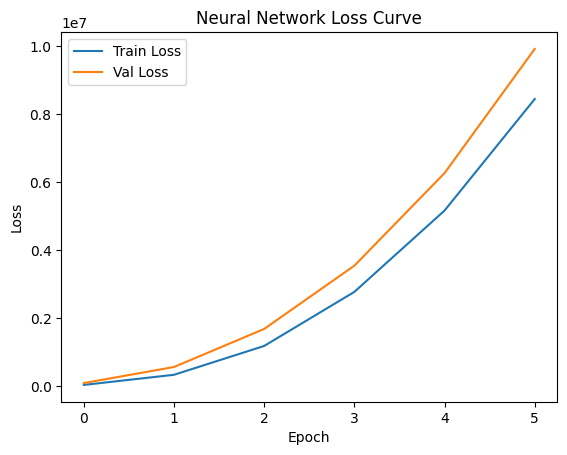

In [63]:
# Plot loss

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title("Neural Network Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [64]:
# Predict and evaluate
y_pred_probs = model.predict(X_test_nn)

# Re-split predictions for each target
start = 0
nn_preds_labels = {}

print("\n Neural Network Evaluation (Per Target Column)\n")
for col in y_test.columns:
    ohe = onehot_targets[col]
    classes = ohe.categories_[0]
    num_classes = len(classes)
    
    probs = y_pred_probs[:, start:start+num_classes]
    preds = np.argmax(probs, axis=1)
    actual = y_test_enc[col].values
    
    acc = accuracy_score(actual, preds)
    f1 = f1_score(actual, preds, average='macro')
    h_loss = hamming_loss(actual, preds)

    decoded_preds = label_encoders[col].inverse_transform(preds)
    decoded_actual = label_encoders[col].inverse_transform(actual)
    nn_preds_labels[col] = (decoded_actual, decoded_preds)

    print(f"{col}")
    print(f"Accuracy     : {acc:.4f}")
    print(f"F1 Score     : {f1:.4f}")
    print(f"Hamming Loss : {h_loss:.4f}\n")

    start += num_classes


172/172 ━━━━━━━━━━━━━━━━━━━━ 0s 420us/step

 Neural Network Evaluation (Per Target Column)

Primary_HL
Accuracy     : 0.0289
F1 Score     : 0.0080
Hamming Loss : 0.9711

Support_HL
Accuracy     : 0.1534
F1 Score     : 0.0380
Hamming Loss : 0.8466

Lifestyle_HL
Accuracy     : 0.4943
F1 Score     : 0.1323
Hamming Loss : 0.5057

Primary_DF
Accuracy     : 0.0284
F1 Score     : 0.0110
Hamming Loss : 0.9716

Support_DF
Accuracy     : 0.4965
F1 Score     : 0.1106
Hamming Loss : 0.5035

Lifestyle_DF
Accuracy     : 0.4541
F1 Score     : 0.1249
Hamming Loss : 0.5459

Primary_GR
Accuracy     : 0.0694
F1 Score     : 0.0186
Hamming Loss : 0.9306



## Why Neural Network Performed Poorly in this Case:

### All Features Are Categorical:
- Neural networks typically thrive on **dense, continuous numeric features**.
- The dataset has **only categorical features**, and even after one-hot encoding, the input becomes **high-dimensional and sparse**, which is harder for NNs to learn from unless you have a **massive dataset**.

### Multiclass Multi-Output Setup:
- NNs are **trickier to train effectively** for **multiclass classification** across **multiple outputs simultaneously**.
- They require **careful architecture tuning** (e.g., output heads with softmax per target, not sigmoid) or even **custom model design** for multi-output multiclass, which isn’t straightforward in Keras’s default setup.

### Small to Medium Dataset Size:
- Tree-based models like **XGBoost** and **Random Forest** handle **small-medium datasets** better, especially when features are **categorical or one-hot encoded**.
- NNs typically need **larger amounts of data** to generalize well.

### Model Simplicity Worked Better:
- **Logistic Regression, Random Forest, and XGBoost** already gave **great accuracy and generalization**.
- In this case, **adding neural networks didn’t bring any advantage** — it **overcomplicates the solution**.
